In [1]:
%matplotlib inline
%load_ext line_profiler
from itertools import combinations
import statistics

import pandas as pd
import numpy as np

import mplfinance as mpl 
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

In [3]:
from trading import create_portfolio, trade, portfolio_value
from strategies import mean_reverting_pairs,  mean_reverting_multi_group

def ceil(n, d):
    return -(n // -d)

In [4]:
from database_query import get_price_data, get_symbols_with_pd

In [119]:
def plot_heatmap(res_table, corr_df=None):
    res_table = res_table.astype('float')
    plt.figure(figsize=(1.1*len(res_table.index.values), 0.74*len(res_table.columns.values)))
    ax = sns.heatmap(res_table, annot=True, fmt=".0f", cmap='PuOr', center=1000)
    
    if corr_df is not None:
        cmap = sns.color_palette('PuOr', as_cmap=True)
        norm = mcolors.Normalize(vmin=-1, vmax=1)  # Normalize to correlation range
        
        rgb_matrix = {
            (i, j): tuple(cmap(norm(corr_df.iloc[i, j]))[:3])
            for i in range(corr_df.shape[0]) for j in range(corr_df.shape[1])
        }
    
        for i, index in enumerate(res_table.index.values):
            for j, col in enumerate(res_table.columns.values):
                if i!=j:
                    ax.add_patch(Rectangle((i,j), 1, 1, ec=rgb_matrix[i,j], fc='none', lw=2))
                
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label("Correlation")    
    
    plt.show()

In [5]:
master = get_price_data(get_symbols_with_pd(), date_range='2024-1-15::2025-1-28', default_cols=['close'])
master.close = master.close.astype('float64')
master.set_index('price_date', inplace=True)

master = master.pivot(columns=['ticker']).dropna()
#master

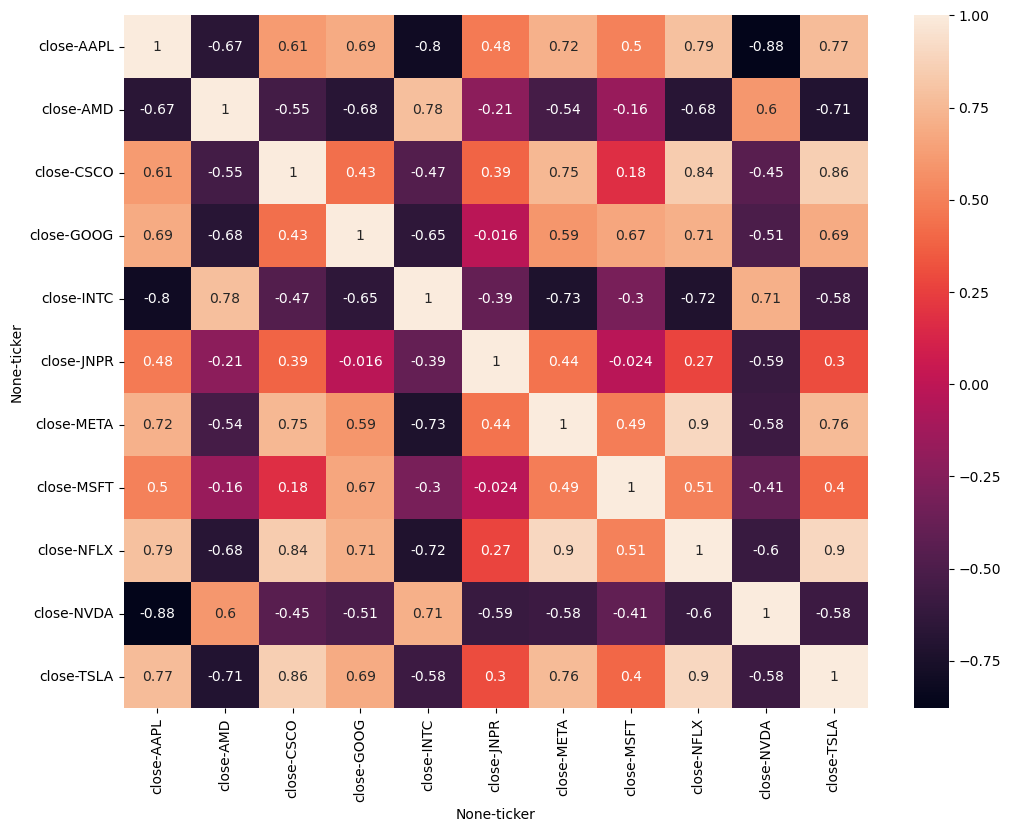

In [104]:
plt.figure(figsize=(12, 9))
corr_df = master.corr()
sns.heatmap(corr_df, annot=True)
plt.show()

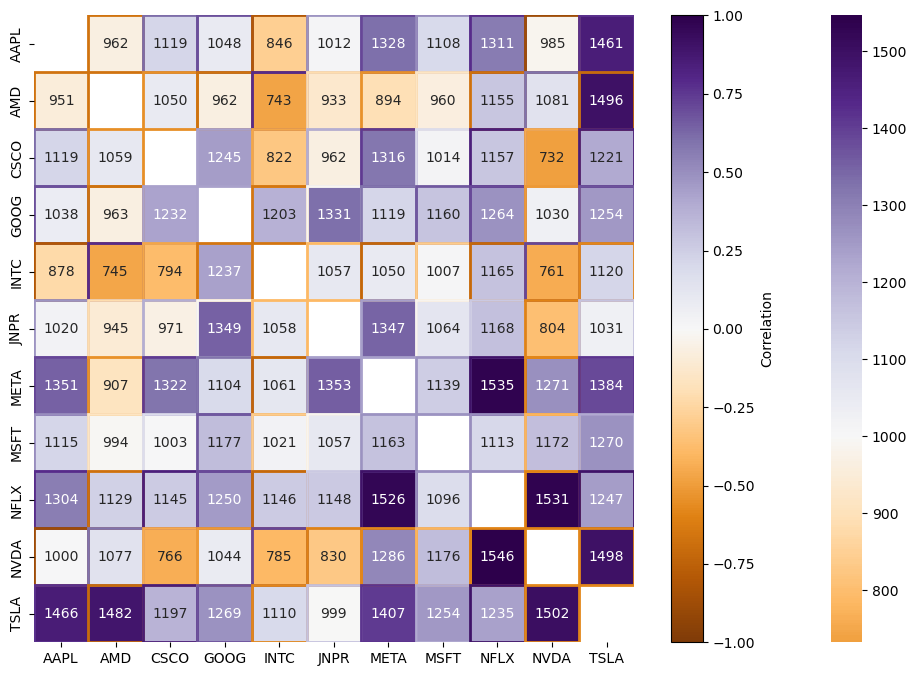

CPU times: total: 14.6 s
Wall time: 39.6 s


In [118]:
%%time
track_value = False
tickers1 = ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA']
tickers2 = ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA']
pairs = [(x,y) for x in tickers1 for y in tickers2 if x!=y]


res = {}
res_table = pd.DataFrame(columns=tickers2, index=tickers1)

for s1,s2 in pairs:

    portfolio = create_portfolio(max_trade_perc=0.1)
    order_book = mean_reverting_pairs(master, s1,s2, pair_trade=True)
    
    for date, order in order_book: 
        portfolio = trade(order, portfolio)
        
    res[f'{s1},{s2}'] = (portfolio, portfolio_value(portfolio, master.loc[date].close))  
    res_table.loc[s1,s2] = res[f'{s1},{s2}'][1]['Total']


plot_heatmap(res_table, corr_df)

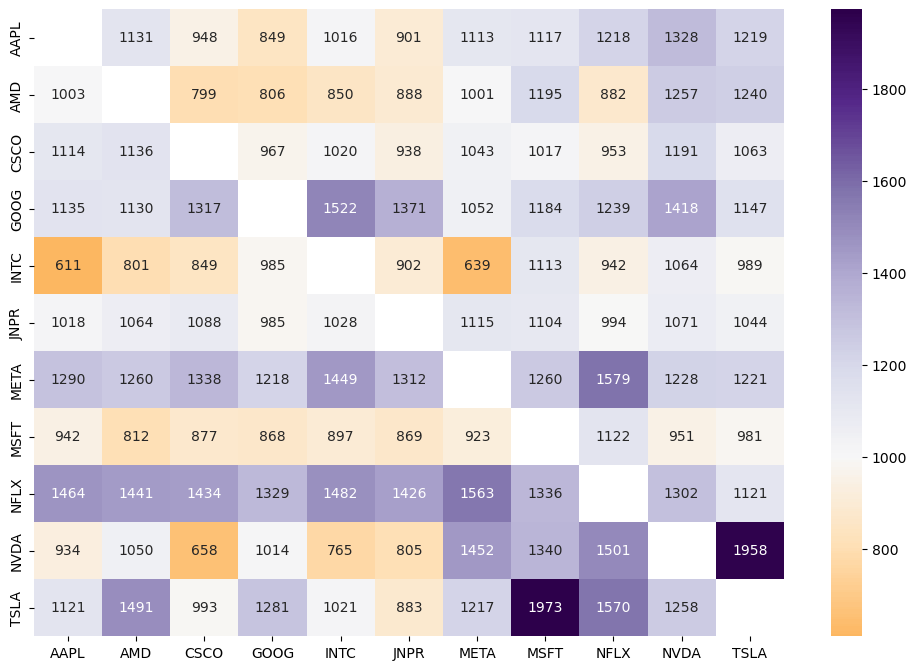

CPU times: total: 5.67 s
Wall time: 13.8 s


In [120]:
%%time
stock_group = ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA']
all_stocks_all_cont = [(i, [j for j in stock_group if j!=i]) for i in stock_group]

#individual_s1 = 'TSLA'
n_contributors = 1
res_table = pd.DataFrame(columns=stock_group, index=stock_group)
m_window = 7
for individual_s1 in stock_group:

    one_stock_n_cont = [(individual_s1, i) for i in list(combinations([i for i in stock_group if i != individual_s1], n_contributors))]
    averages = {i:[]for i in stock_group if i!=individual_s1}
    
    for pair in one_stock_n_cont:
        res = {}
        
        portfolio = create_portfolio(max_trade_perc=0.3)
        order_book = mean_reverting_multi_group(master,pair[0],pair[1], m_window)
        
        for date, order in order_book:   
            portfolio = trade(order, portfolio)
            
        res = (portfolio, portfolio_value(portfolio, master.loc[date].close))  
    
        for contributor in pair[1]:
            averages[contributor].append(res[1]['Total'])
    
    for s2 in averages:
        res_table.loc[individual_s1,s2] = statistics.mean(averages[s2])
 
plot_heatmap(res_table)